# Initialize (non machine-specific parameters)

In [2]:
import pandas as pd # version 0.16.0 or later
import numpy as np
import datetime
import csv
import os
from matplotlib import pyplot as plt
from datetime import datetime

def variablename(var):
    return [tpl[0] for tpl in
    filter(lambda x: var is x[1], globals().items())]

def get_df_name(df):
    name =[x for x in globals() if globals()[x] is df][0]
    return name
    #returns df's name to string

def get_df(str0):
    return globals()[str0]
    #returns df

colnames_base=",'epoch','seconds','zom','ch','fy','ref','i1','testfy','ctemp','i0','sc']"
Skiprow='14'
Epoch_offset=2133 #Epoch_132=Epoch_ssrl+2133


Scan_R_dict=[(390,440,'N'),(445,480,'Ti'),(455,490,'Ru'),(510,560,'O'),(620,680,'Mn'),(765,820,'Co'),(835,890,'Ni')]
Norm_L_dict=[(393,395,'N'),(453,454,'Ti'),(520,527,'O')]
Norm_H_dict=[(408,411,'N'),(468,469,'Ti'),(544,546,'O')]

belowedge=[393,395]
aboveedge=[408,411]


import math
stick_width=19.05
SampleX_min=0
SampleZ_min=455.5
R_cen=[(6,0,455.25),(6,0,455.25),(6,0,455.25),(6,0,454)]

'''
def samplename_from_xyzr(df_sample,x,y,z,r):
    RR=r%90
    stick_width=19.05
    #X_cenRR=(df_sample['X_cen'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +1*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min
    df_sample['X_minR']=(df_sample['X_min'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min
    df_sample['X_maxR']=(df_sample['X_max'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min

    #samplename=df_sample[(df_sample['X_minR'] <= x) & (df_sample['X_maxR']  >= y)  &  (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["name"]
    #samplename=df_sample[(X_minRR <= x) & (X_maxRR  >= y)  &  (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["name"]
    samplename=df_sample[ (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["SAMPLE"]

    if len(samplename)!=0:
        return(samplename.tolist()[0])
    elif z < SampleZ_min:
        return('photodiode')
    else:
        return(None)

def sampleid_from_xyzr(df_sample,x,y,z,r):

    RR=r%90
    stick_width=19.05
    df_sample['X_minR']=(df_sample['X_min'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min
    df_sample['X_maxR']=(df_sample['X_max'])*math.sin(RR/180*math.pi)-np.sqrt(2)*(stick_width/2-df_sample['Y_cen'])*math.cos((90+45-RR)/180*math.pi)  +df_sample['R_cenX']*math.cos((90+45-RR)/180*math.pi) #df_sample['R_cenX']#+df_sample['R_cenX']#-math.sin(15/180*math.pi)*stick_width+SampleX_min

    #sampleid=df_sample[(df_sample['X_minR'] <= x) & (df_sample['X_maxR']  >= x)  &  (df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["Sample_ID"]
    sampleid=df_sample[(df_sample['Z_min'] <= z) & (df_sample['Z_max']  >= z) &(df_sample['R_min']<= r) & (df_sample['R_max']  >= r)]["ID"]

    if len(sampleid)!=0:
        return(sampleid.tolist()[0])
    else:
        return(None)

def scanstring_from_mono132(M0):
    for i in range(len(Scan_R_dict)):
        if ((M0 <= float(Scan_R_dict[i][1])) &  (M0 >= float(Scan_R_dict[i][0]))):
            return(Scan_R_dict[i][2])
    return('')
'''
def normlow_from_scanstring(M0):
    for i in range(len(Norm_L_dict)):
        if ((M0 == (Norm_L_dict[i][2]))):
            return(Norm_L_dict[i][0],Norm_L_dict[i][1])
    return('')
def normhigh_from_scanstring(M0):
    for i in range(len(Norm_H_dict)):
        if ((M0 ==(Norm_H_dict[i][2]))):
            return(Norm_H_dict[i][0],Norm_H_dict[i][1])
    return('')




# Initiualize (session specific parameters)

In [14]:
DirSeparator='/'
default_mydrive_path='/Users/hirohito/data/'
default_data_foldername='20250627'

print("Directory structure (exmaple)")
print("In this exmaple:\n mydrive_path=/Users/data \n data_foldername = 20240615")
print()
print("/Users/data/20240622/spec/")
print("/Users/data/20240622/spec_alias/")
print("/Users/data/20240622/spec_nobg/")
print()
mydrive_path = input("Enter the path of your mydrive_path:")
data_foldername = input("Enter the name of your data_foldername")
if len(mydrive_path) == 0:
    mydrive_path=default_mydrive_path
if len(data_foldername)==0:
    data_foldername=default_data_foldername
print()
print('mydrive_path = ',mydrive_path)
print('data_foldername = ',data_foldername)

# This is the configuration to analyze files on Local Drive
# Need to copy data files to Local Drive
#data_foldername='20250627'
#experiment=["20250627"] #list
experiment=[data_foldername]
#mydrive_path='/Users/hirohito/data/'

os.chdir(mydrive_path)
dir = mydrive_path+"pandas"
if not os.path.exists(dir):
    os.makedirs(dir)
    print()
    print('I created '+dir)

Directory structure (exmaple)
In this exmaple:
 mydrive_path=/Users/data 
 data_foldername = 20240615

/Users/data/20240622/spec/
/Users/data/20240622/spec_alias/
/Users/data/20240622/spec_nobg/



Enter the path of your mydrive_path: 
Enter the name of your data_foldername 



mydrive_path =  /Users/hirohito/data/
data_foldername =  20250627


# This is the configuration to analyze files using Google Collab + Google Drive
# Need to copy data files under MyDrive
from google.colab import drive
drive.mount('/content/gdrive')
mydrive_path='/content/gdrive/MyDrive/'
data_foldername='SSRL_BL132/6739/data/'
home=mydrive_path+data_foldername
DirSeparator='/'
os.chdir(home)
dir = home+"pandas"
if not os.path.exists(dir):
    os.makedirs(dir)

In [18]:
df_sample

,Epoch,PST,C02,C03,C04,C05,PDT,C07,C08,Scan_number,...,Sample_position,C11,C12,C13,C14,Column_id,C15,Row_id,Sample_id,Sample_name
0,1751066909.0,Fri,Jun,27,17:04:02,2025.0,NaN,htxs_comment,scan,22:,...,"(x,y,z)=(6,0,6)",mono,537.999,eV,side,1,sample,1,(101):,LCO_P.
1,1751067225.0,Fri,Jun,27,17:09:18,2025.0,NaN,htxs_comment,scan,23:,...,"(x,y,z)=(6,0,6)",mono,537.999,eV,side,1,sample,1,(101):,LCO_P.
2,1751067505.0,Fri,Jun,27,17:13:58,2025.0,NaN,htxs_comment,scan,24:,...,"(x,y,z)=(6,0,6)",mono,537.999,eV,side,1,sample,1,(101):,LCO_P.
3,1751067805.0,Fri,Jun,27,17:18:58,2025.0,NaN,htxs_comment,scan,25:,...,"(x,y,z)=(6,0,6)",mono,537.999,eV,side,1,sample,1,(101):,LCO_P.
4,1751068106.0,Fri,Jun,27,17:23:59,2025.0,NaN,htxs_comment,scan,26:,...,"(x,y,z)=(6,0,6)",mono,537.999,eV,side,1,sample,1,(101):,LCO_P.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,1751267964.0,Mon,Jun,30,00:54:57,2025.0,NaN,htxs_comment,scan,520:,...,"(x,y,z)=(6,0,7)",mono,315.000,eV,side,2,sample,4,(204):,PPLN_GrR3.
451,1751268564.0,Mon,Jun,30,01:04:57,2025.0,NaN,htxs_comment,scan,521:,...,"(x,y,z)=(6,0,6)",mono,315.000,eV,side,2,sample,5,(205):,PPLN_Mask.
452,1751268864.0,Mon,Jun,30,01:09:57,2025.0,NaN,htxs_comment,scan,522:,...,"(x,y,z)=(6,0,6)",mono,315.000,eV,side,2,sample,5,(205):,PPLN_Mask.
453,1751269464.0,Mon,Jun,30,01:19:57,2025.0,NaN,htxs_comment,scan,523:,...,"(x,y,z)=(6,0,6)",mono,315.000,eV,side,2,sample,5,(205):,PPLN_Mask.


In [17]:
#htxs_commnets purser
#Not needed
colnames_sample=['Epoch','PST','C02','C03','C04','C05','PDT','C07','C08','Scan_number','Scan_type','C09','C10','Sample_position','C11','C12','C13','C14','Column_id','C15','Row_id','Sample_id','Sample_name']
inputFile= mydrive_path+data_foldername+DirSeparator+'htxs_comments'
#inputFile=DirSeparator='/'+'htxs_comments'

df_sample = pd.read_csv(inputFile, names=colnames_sample, header=None,sep=' ')

for i, j in df_sample.iterrows():
    #print(j.iloc[2],j.iloc[3],j.iloc[4],int(j.iloc[5]))
    date_string = str(int(j.iloc[5]))+'-'+str(j.iloc[2])+'-'+str(j.iloc[3])+' '+str(j.iloc[4])
    #print(df_sample.iloc[0:2])
    date_format = "%Y-%M-%d %H:%M:%S"
    date_object = datetime.strptime(str(j.iloc[2]), "%b")
    year_number=int(j.iloc[5])
    month_number = date_object.month
    date_number=int(j.iloc[3])
    date_object = datetime.strptime(str(j.iloc[4]), "%H:%M:%S")
    hour_number = date_object.hour
    minute_number = date_object.minute
    second_number = date_object.second
    #print(hour_number, minute_number,second_number)

    #from datetime import datetime
    dt = datetime(year_number, month_number, date_number, hour_number, minute_number,second_number)

    epoch_time = dt.timestamp()
    df_sample.iloc[i,0]=epoch_time-Epoch_offset
    j.iloc[0]=epoch_time
    #print(j.iloc[0],epoch_time)


# XAS

In [48]:
!rsync -av --bwlimit=1M bl132lx:~/data/20250627 ~/data

/etc/profile.d/lang.sh: line 19: warning: setlocale: LC_CTYPE: cannot change locale (C.UTF-8)
perl: warning: Setting locale failed.
perl: warning: Please check that your locale settings:
	LANGUAGE = (unset),
	LC_ALL = (unset),
	LC_CTYPE = "C.UTF-8",
	LANG = "en_US.UTF-8"
    are supported and installed on your system.
perl: warning: Falling back to the standard locale ("C").
Transfer starting: 1127 files
20250627/htxs_comments
20250627/spec/
20250627/spec/htxs
20250627/spec/htxs_scan591.csv
20250627/spec/htxs_scan592.csv
20250627/spec_alias/
20250627/spec_alias/tes_d30_z5_LCO_P_591 -> ../spec/htxs_scan591.csv
20250627/spec_nobg/htxs_nobg
20250627/spec_nobg/htxs_xas

sent 42976 bytes  received 105298 bytes  1482740000 bytes/sec
total size is 25778510  speedup is 173.86


In [38]:
load_list=[]
for _experiment in experiment:
    pathstr=mydrive_path+data_foldername+DirSeparator+'spec_alias/'
    for x in os.listdir(pathstr):
        load_list.append(x)
load_list.sort()
dir = mydrive_path+data_foldername+DirSeparator+"plots"
if not os.path.exists(dir):
    os.makedirs(dir)

In [39]:
df_X = pd.DataFrame()
for k in load_list:
    colnameslist = ["Sample","mono132",  "Seconds", "I0", "SC","ZOM", "CH","FY","REF", "I1", "testfy", "CTEMP"]   
    df_temp=pd.read_csv(mydrive_path+data_foldername+DirSeparator+"spec_alias/" +k,comment='#',names=colnameslist,sep=',',skiprows=1)
    df_temp['Sample']=k
    #df_X=appended_df = pd.concat([df_X, df_temp], ignore_index=True)
    df_X= pd.concat([df_X, df_temp], ignore_index=True)
df_X.to_csv(mydrive_path+data_foldername+DirSeparator+'pandas/'+'specdatafrane.csv', index=False) 

In [25]:
df_temp

,Sample,mono132,Seconds,I0,SC,ZOM,CH,FY,REF,I1,testfy,CTEMP
0,xc1s_d15_z7_PPLN_GrR3_520,279.001,0.9,77736,269,7643,0,7683,140,5206,1234.8,0
1,xc1s_d15_z7_PPLN_GrR3_520,279.200,0.9,77851,292,7604,0,7760,140,5249,1298.7,0
2,xc1s_d15_z7_PPLN_GrR3_520,279.400,0.9,78031,314,7646,0,7729,138,5233,1229.4,0
3,xc1s_d15_z7_PPLN_GrR3_520,279.601,0.9,78029,332,7630,0,7759,139,5251,1264.5,0
4,xc1s_d15_z7_PPLN_GrR3_520,279.799,0.9,79221,349,7629,0,7784,139,5322,1309.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
224,xc1s_d15_z7_PPLN_GrR3_520,313.999,0.9,5908,471,7609,0,3765,133,1348,59.4,0
225,xc1s_d15_z7_PPLN_GrR3_520,314.250,0.9,5944,469,7628,0,3805,134,1347,81.9,0
226,xc1s_d15_z7_PPLN_GrR3_520,314.501,0.9,5986,470,7648,0,3790,134,1350,78.3,0
227,xc1s_d15_z7_PPLN_GrR3_520,314.750,0.9,6045,471,7672,0,3779,134,1352,62.1,0


SC=df_X[df_X['Sample']=='xc1s_d15_z5_III_S1_185']['SC']
I0=df_X[df_X['Sample']=='xc1s_d15_z5_III_S1_185']['I0']
X=df_X[df_X['Sample']=='xc1s_d15_z5_III_S1_185']['mono132']
Y=SC/I0

Do you want to review i0 struture? (Y/N): y
Enter scan type? : xc1s


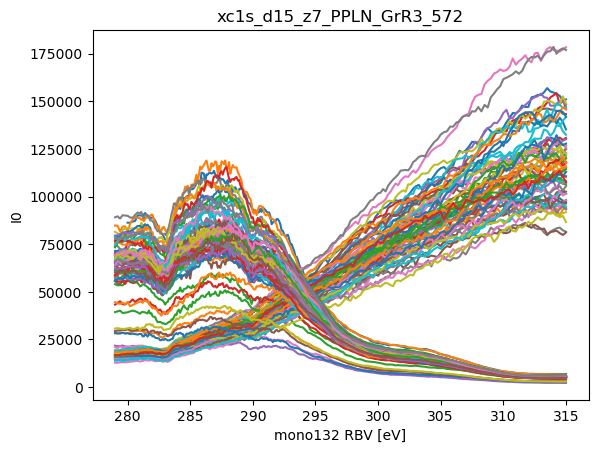

In [47]:
responce = input("Do you want to review i0 struture? (Y/N):")
if responce == 'y' or 'Y': 
   #query_string_sample = input("Enter sample name? :")
   query_string_scan = input("Enter scan type? :")
   #query_string_angle = input("Enter angle? :")
   
# strucutre
#i=0
   for k in load_list:
      #savefilename=home+'plots/'+k+'.pdf'
      SC=df_X[df_X['Sample']==k]['SC']
      FY=df_X[df_X['Sample']==k]['FY']
      TESTFY=df_X[df_X['Sample']==k]['testfy']
      I0=df_X[df_X['Sample']==k]['I0']
      X=df_X[df_X['Sample']==k]['mono132']
      col_label0='I0'
    #Y0=pd.DataFrame
      Y0=I0
    #Y1=FY/I0
    #Y2=TESTFY/I0
      #df_temp=pd.concat([X,Y0,Y1,Y2],axis=1)
    #col_label0='SC_I0normd'
    #col_label0='SC_I0normd'
      #df_temp=df_temp.rename(columns={0: col_label0,1: col_label1,2: col_label2})
      #df_temp.to_csv(home+'pandas/'+k+'.csv',index=False)
      #if len(query_string_sample) == 0:
      #if len(query_string_scan) == 0 
      #if len(query_string_angle)==0: 
      #if len(query_string_sample) == 0:
      #if query_string_sample in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:
      if query_string_scan in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:
      #if query_string_angle in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:         
         plt.plot(X,Y0)
         plt.title(k)
         plt.ylabel(col_label0)
         plt.xlabel('mono132 RBV [eV]') 
       #savefilename=home+'plots/'+k+col_label0+'.pdf'
       #plt.savefig(savefilename)
         plt.show
       #plt.figure()
        
        

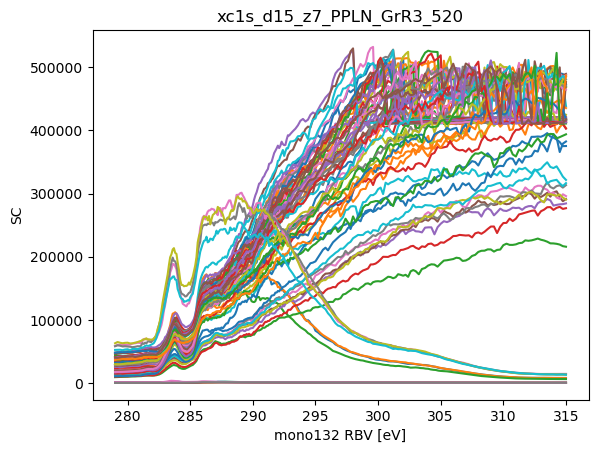

In [80]:
#Review SC strucutre
i=0
for k in load_list:
    #savefilename=home+'plots/'+k+'.pdf'
    SC=df_X[df_X['Sample']==k]['SC']
    FY=df_X[df_X['Sample']==k]['FY']
    TESTFY=df_X[df_X['Sample']==k]['testfy']
    I0=df_X[df_X['Sample']==k]['I0']
    X=df_X[df_X['Sample']==k]['mono132']
    col_label0='SC'
    #Y0=pd.DataFrame
    Y0=SC
    #Y1=FY/I0
    #Y2=TESTFY/I0
    df_temp=pd.concat([X,Y0,Y1,Y2],axis=1)
    #col_label0='SC_I0normd'
    #col_label0='SC_I0normd'
    df_temp=df_temp.rename(columns={0: col_label0,1: col_label1,2: col_label2})
    df_temp.to_csv(home+'pandas/'+k+'.csv',index=False)
    if 'xc1s' in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:
       plt.plot(X,Y0)
       plt.title(k)
       plt.ylabel(col_label0)
       plt.xlabel('mono132 RBV [eV]') 
       #savefilename=home+'plots/'+k+col_label0+'.pdf'
       #plt.savefig(savefilename)
       plt.show
       #plt.figure()

/var/folders/s_/fqjgzzf16vn2ptt52spvkm_959ty5z/T/ipykernel_23323/4034856350.py:38: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


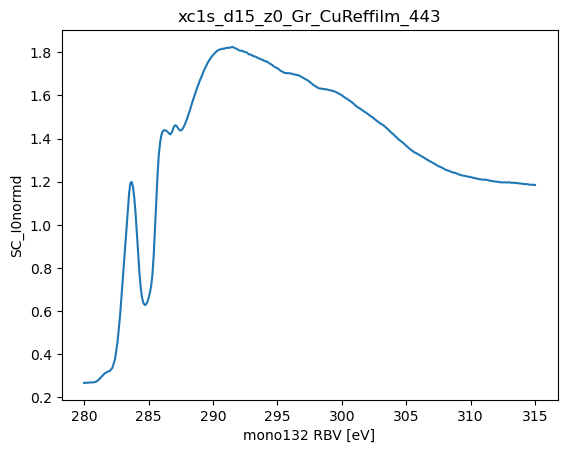

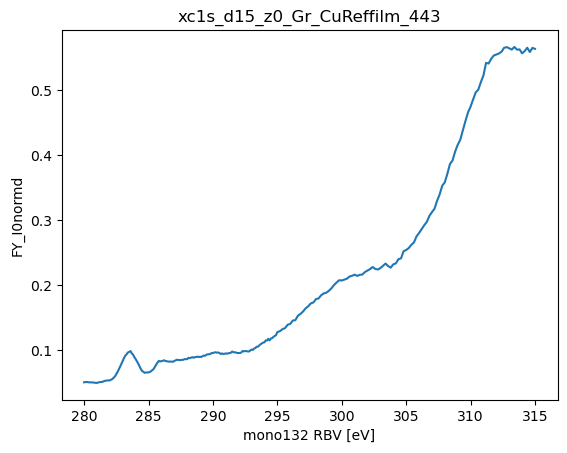

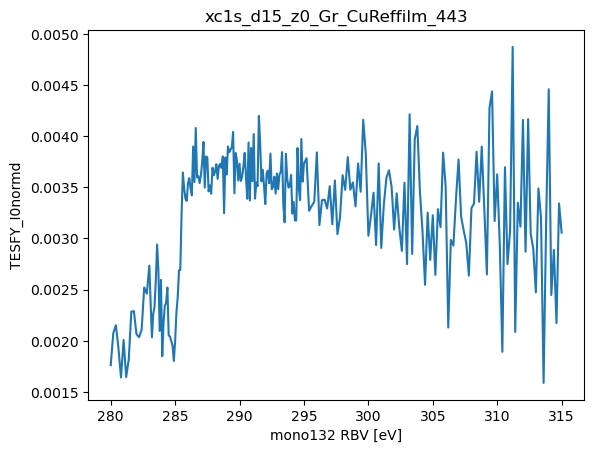

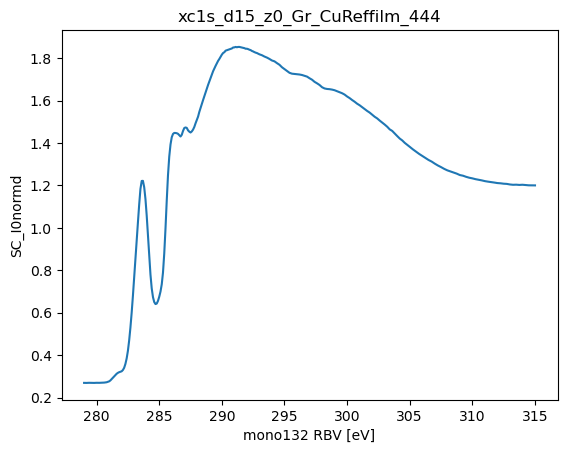

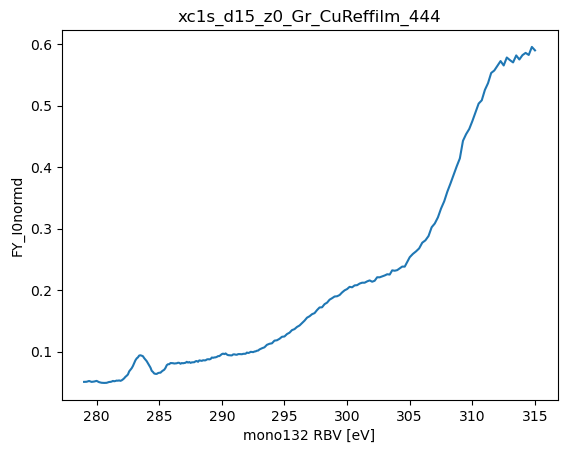

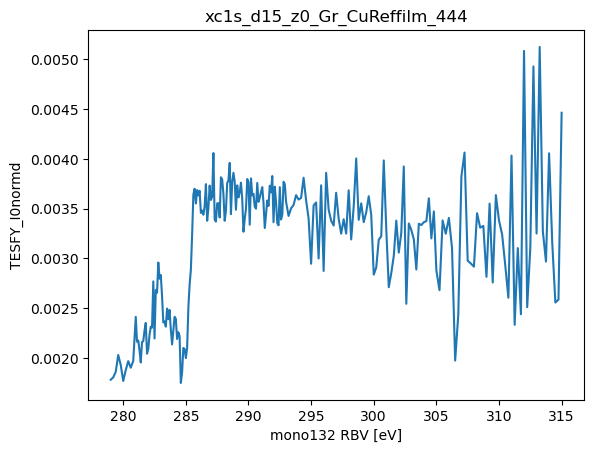

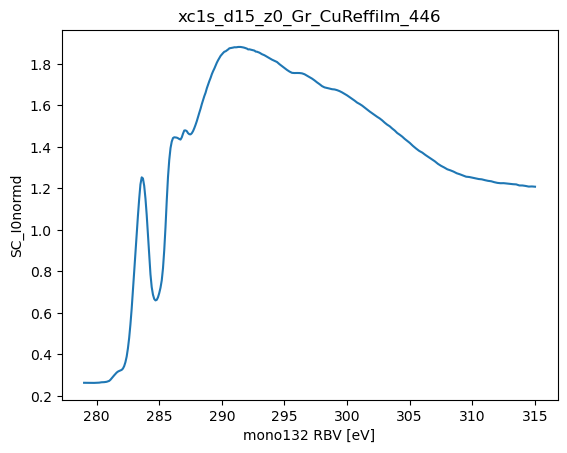

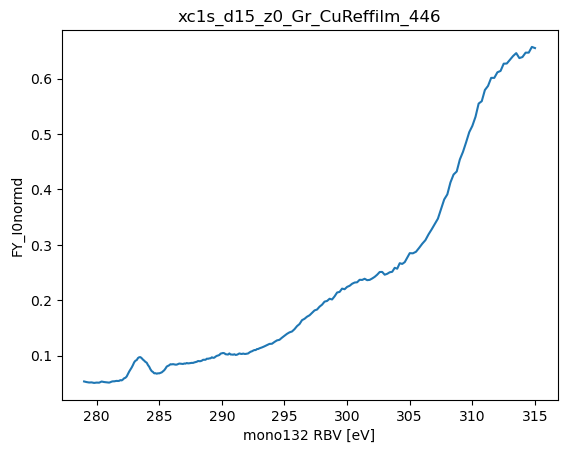

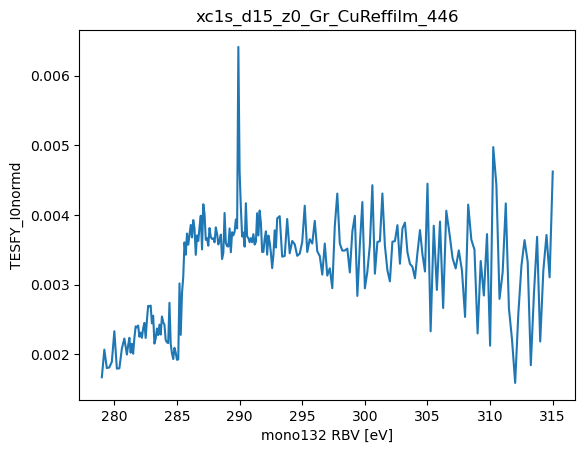

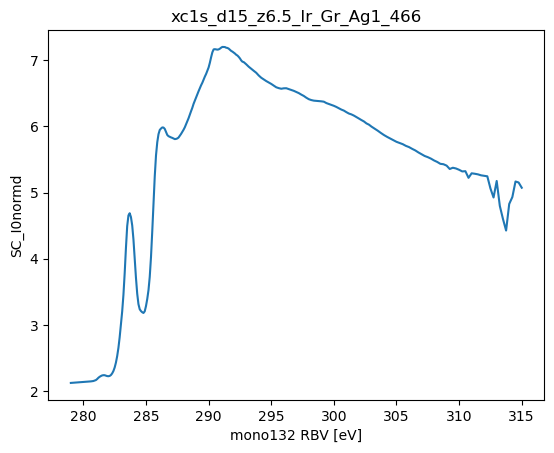

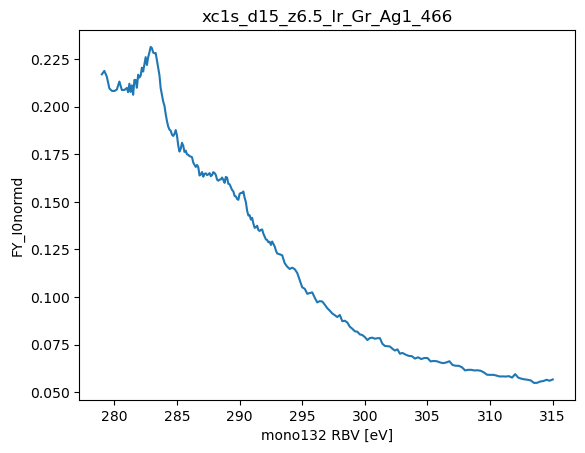

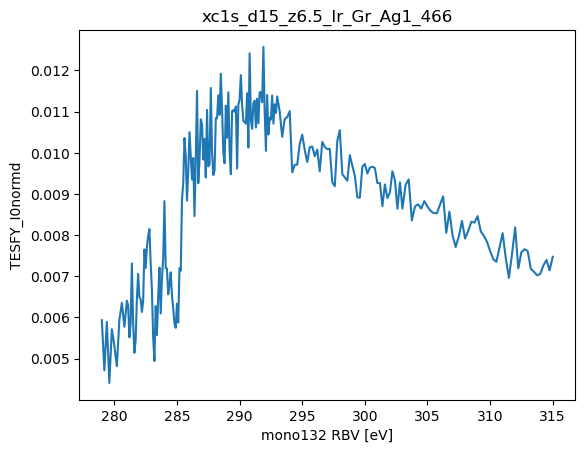

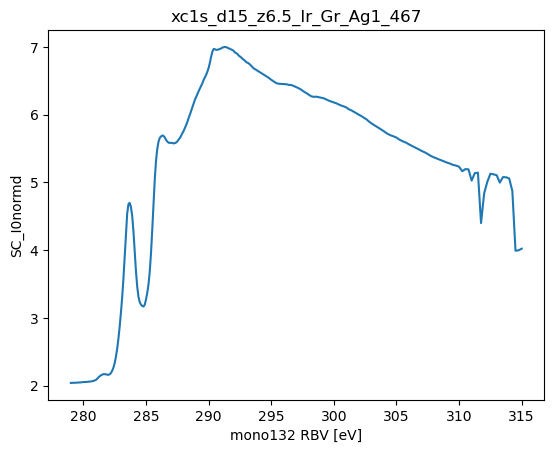

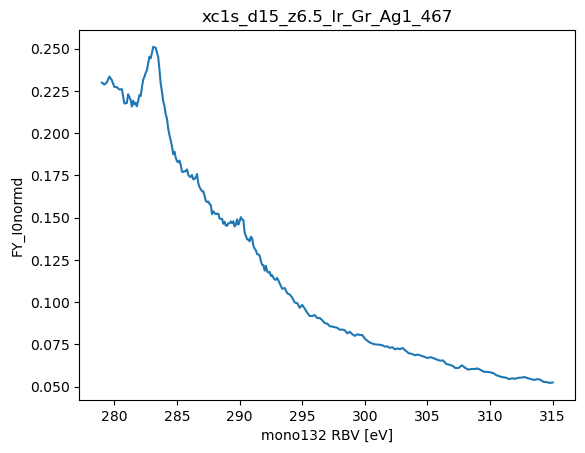

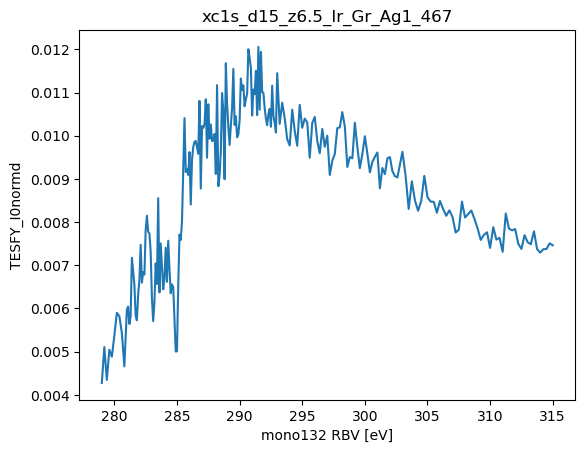

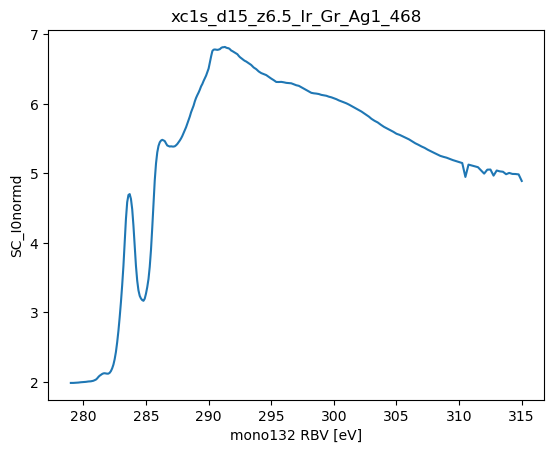

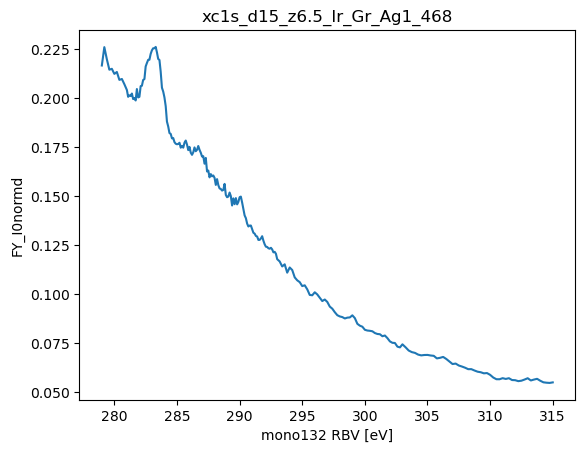

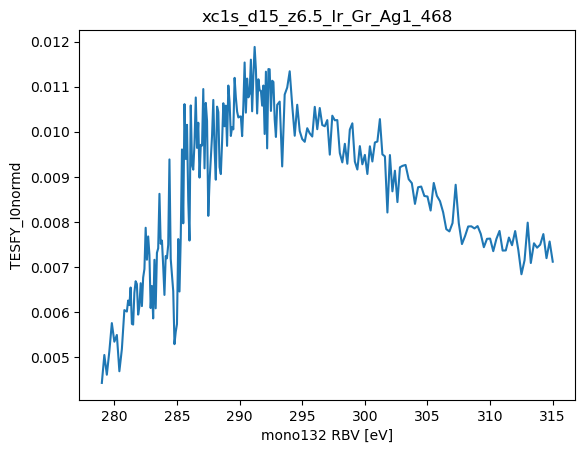

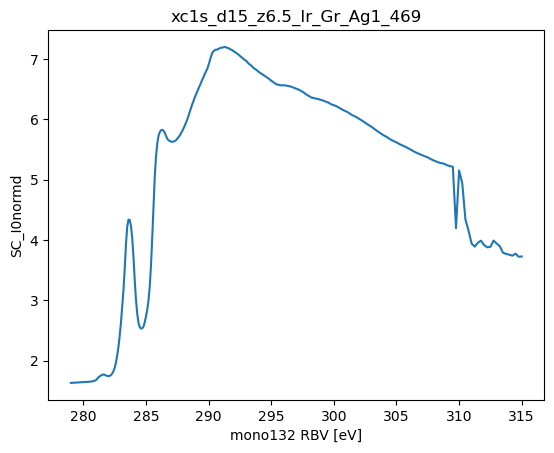

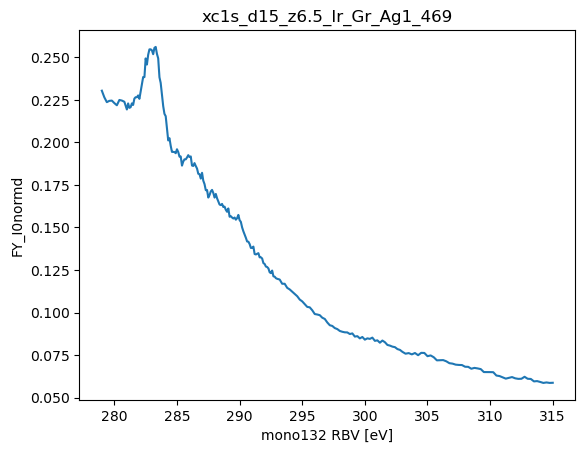

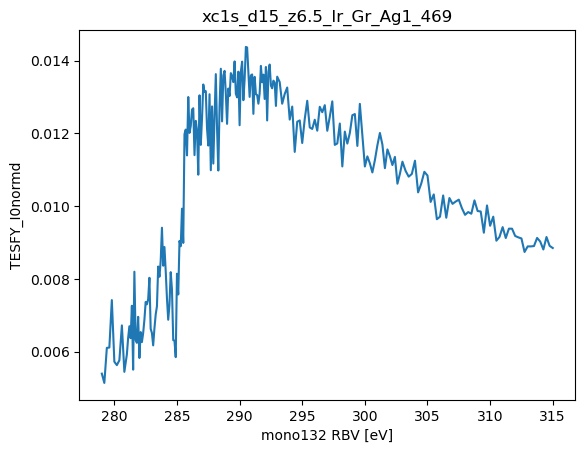

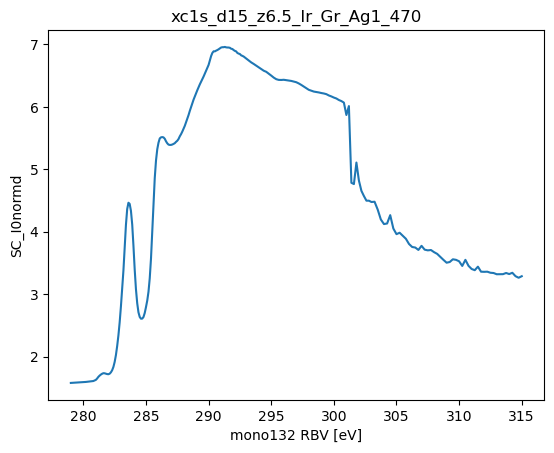

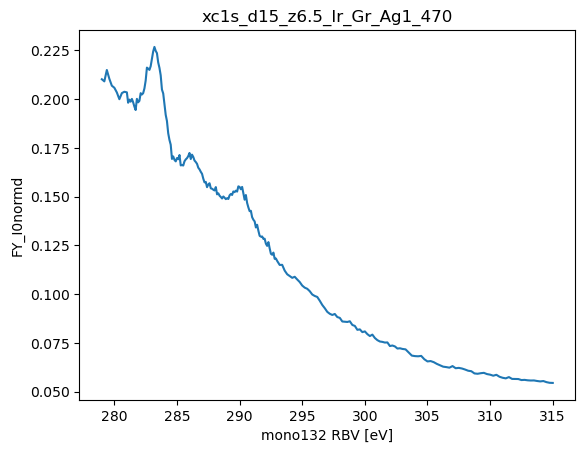

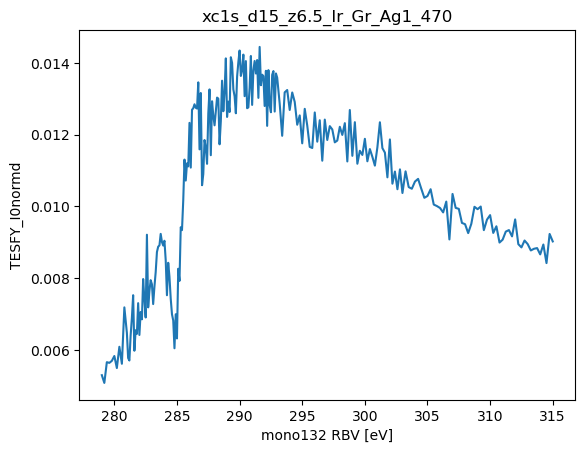

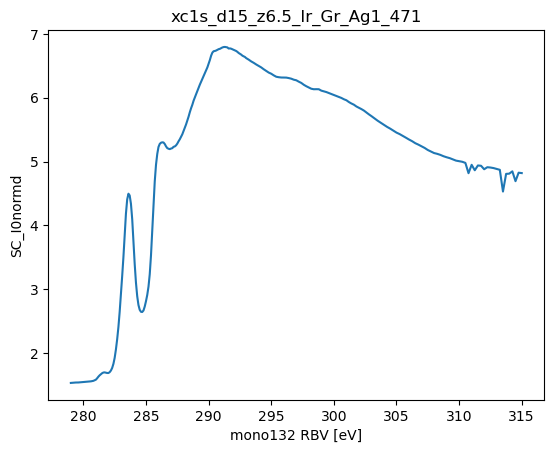

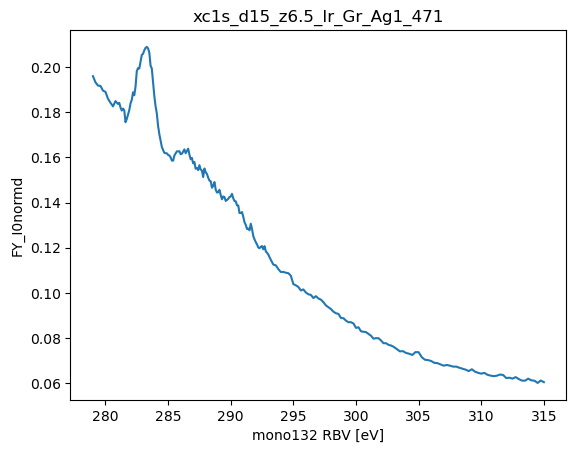

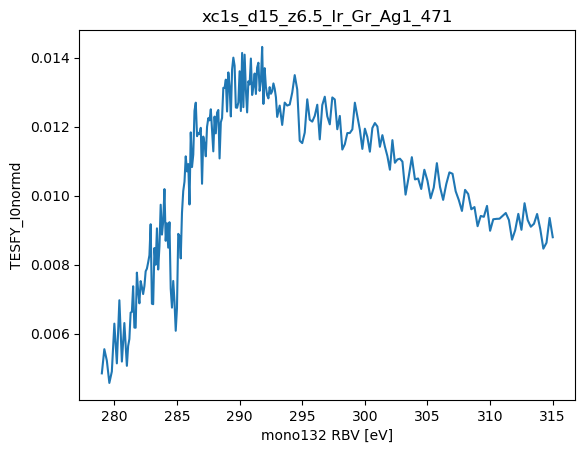

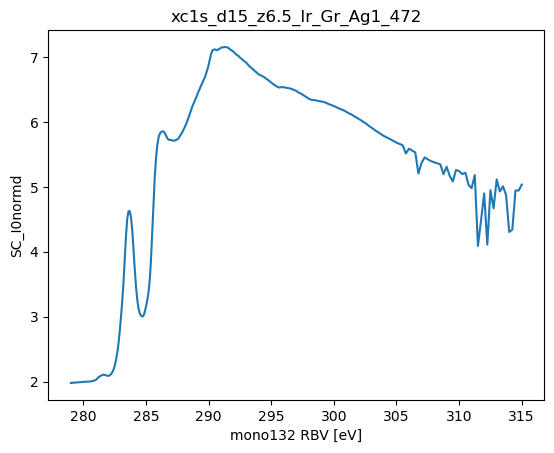

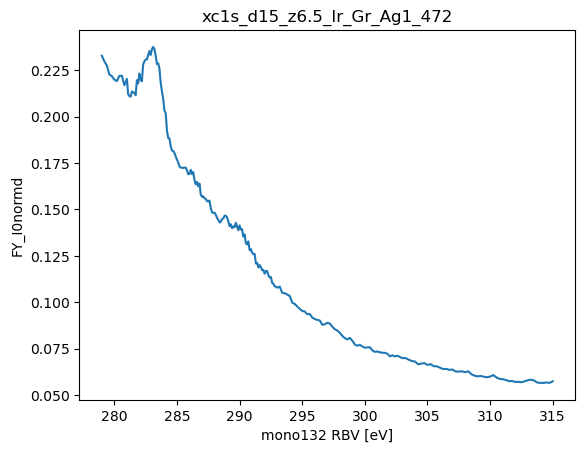

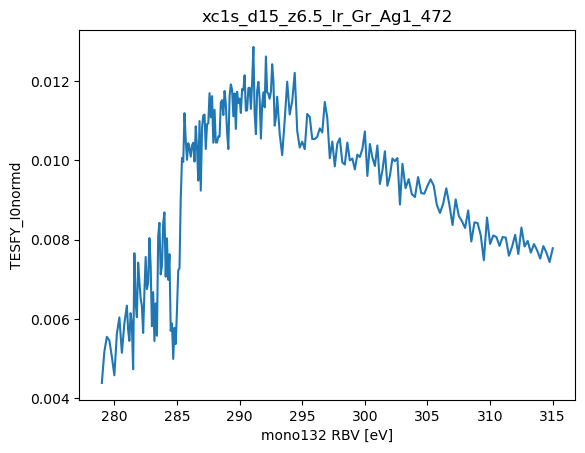

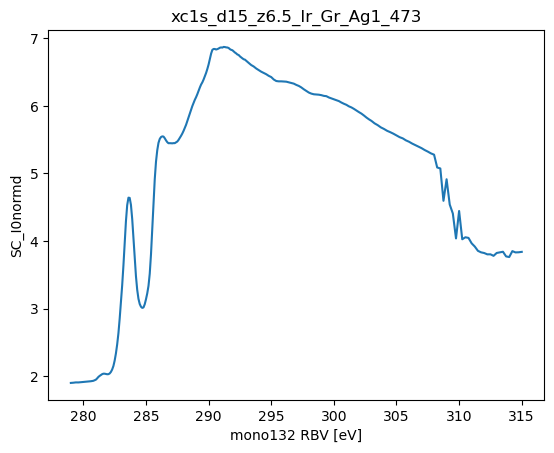

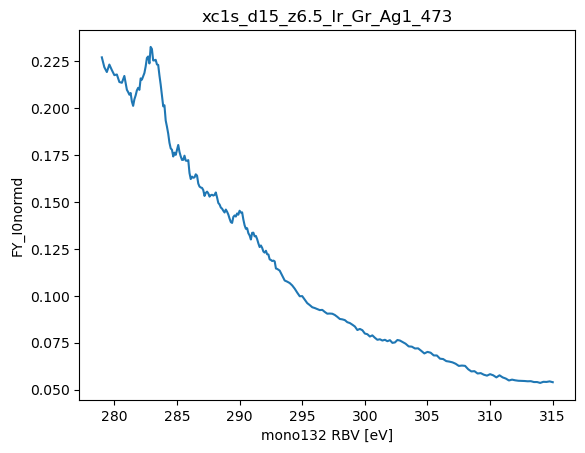

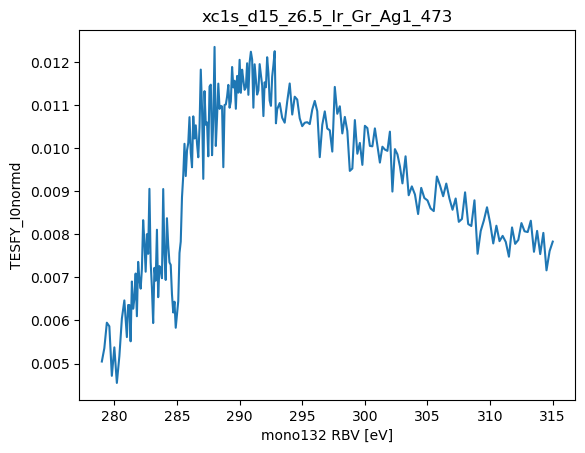

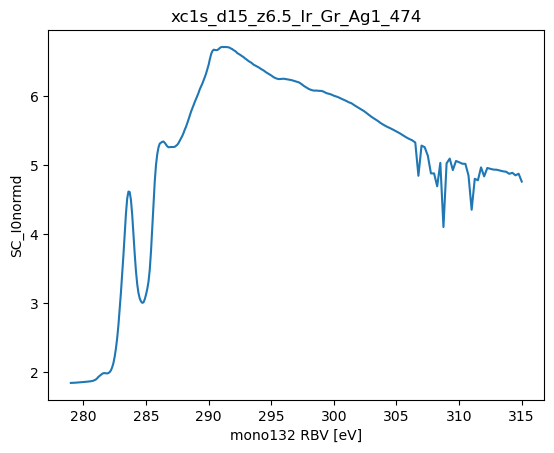

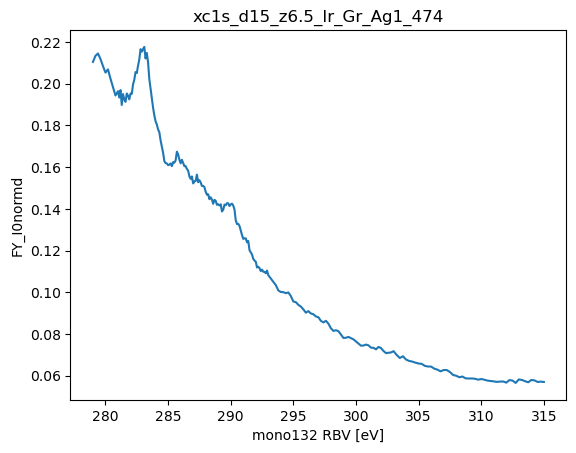

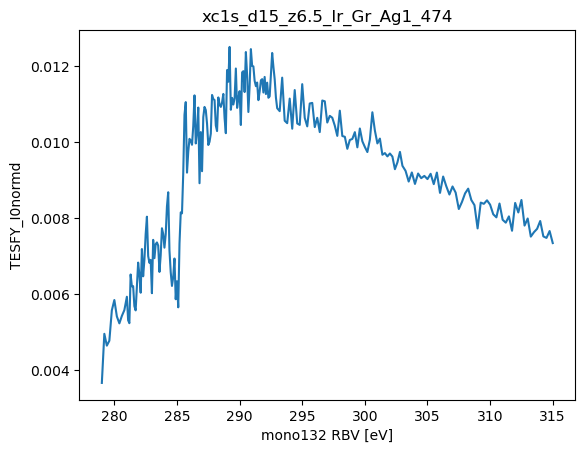

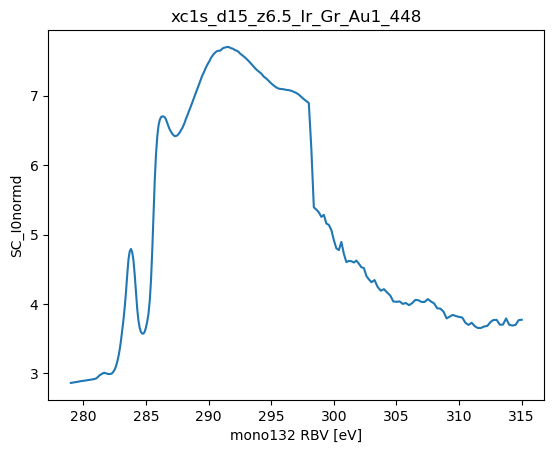

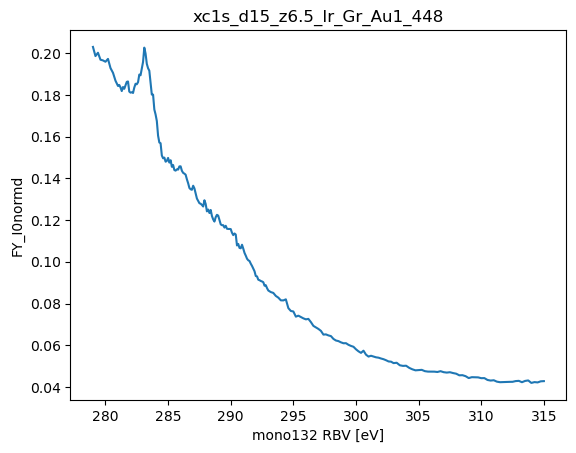

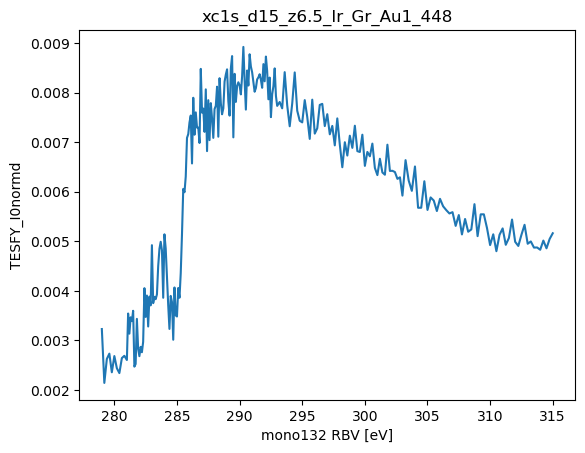

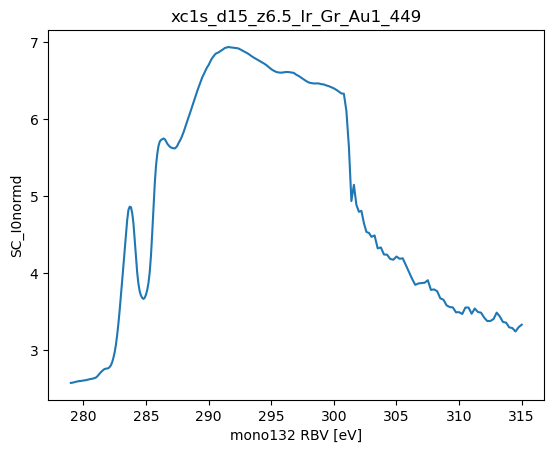

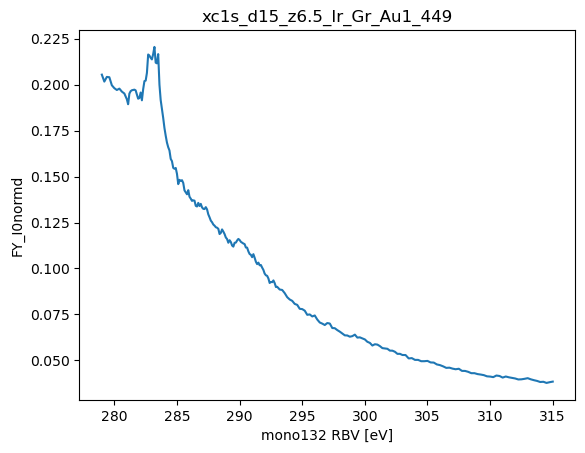

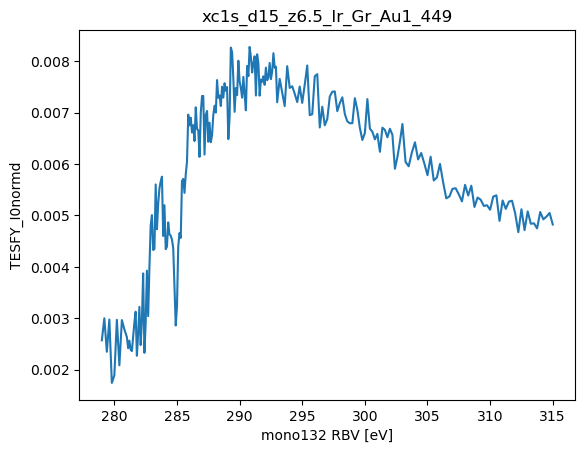

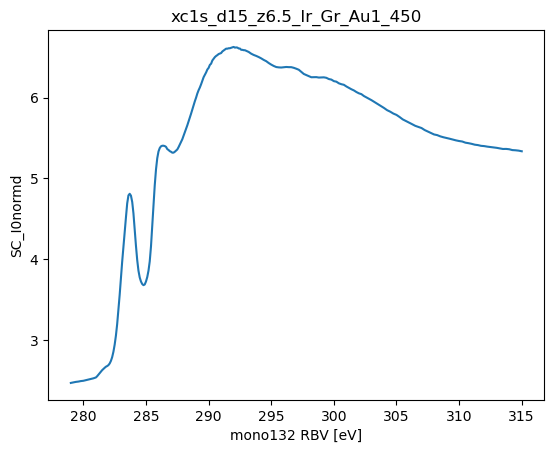

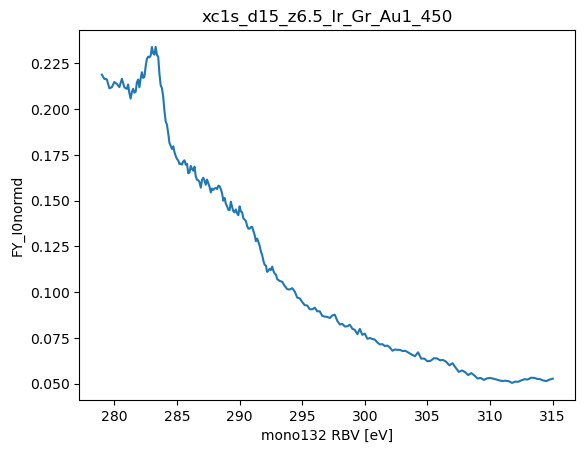

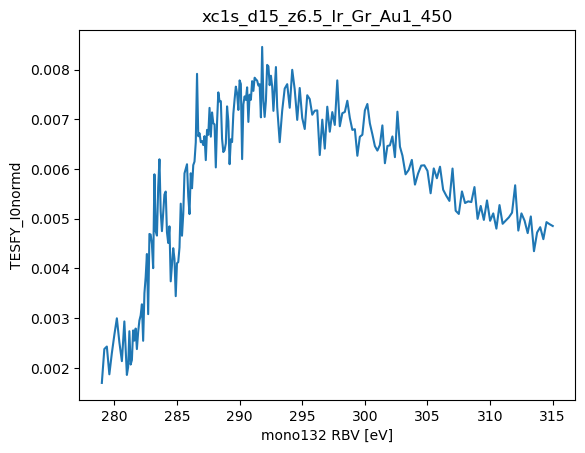

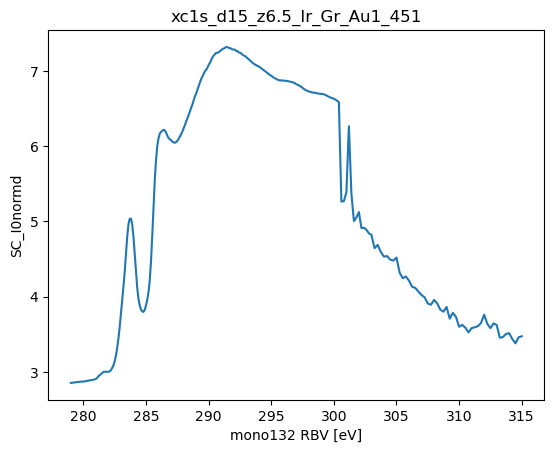

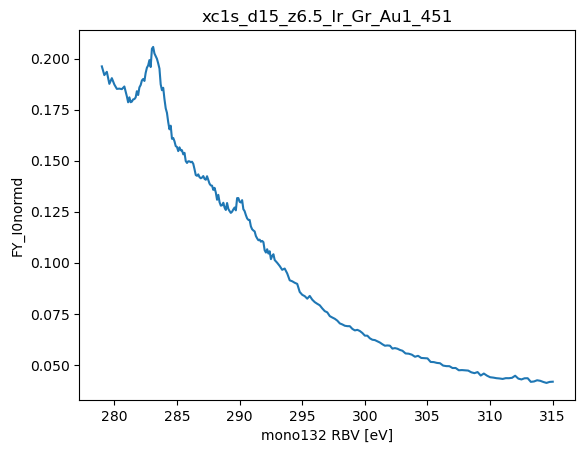

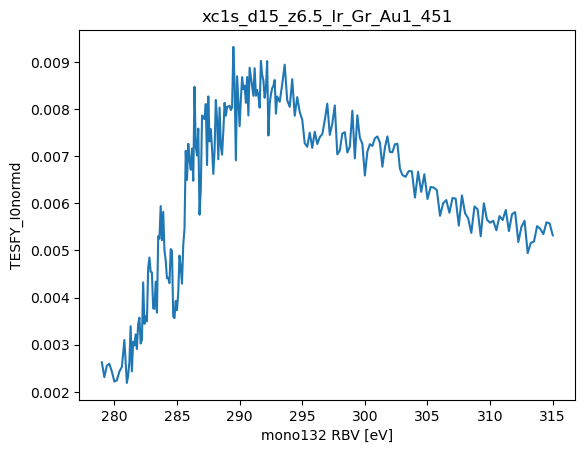

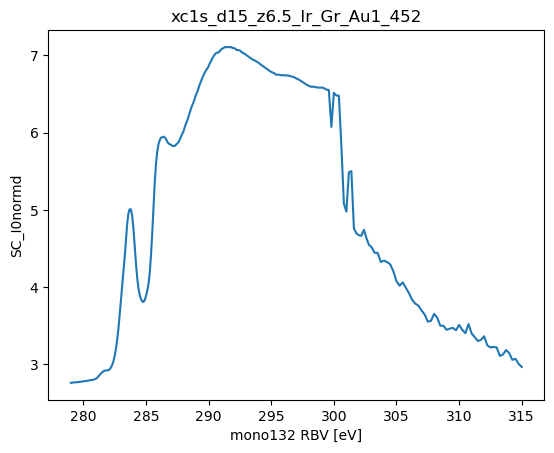

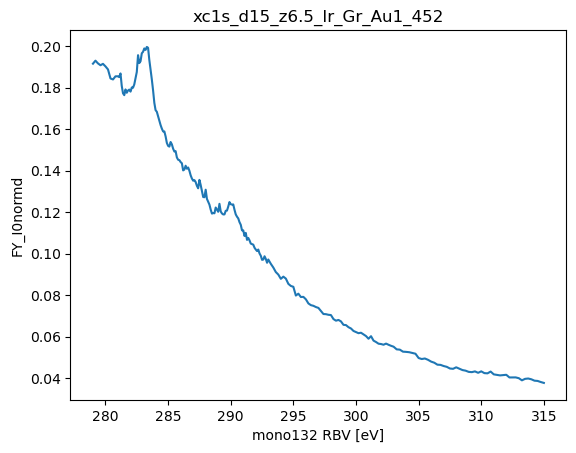

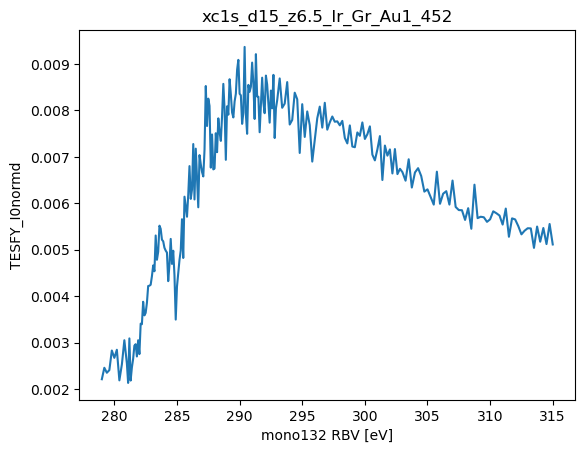

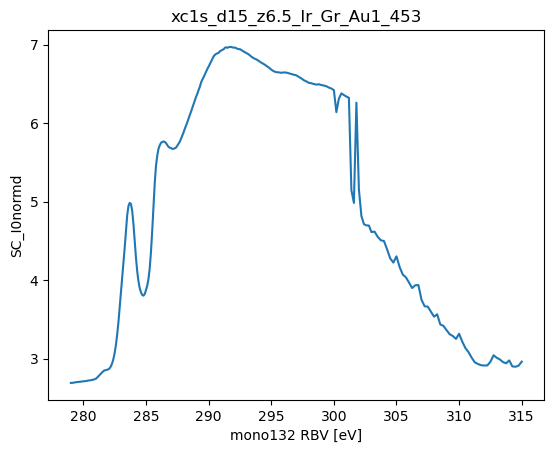

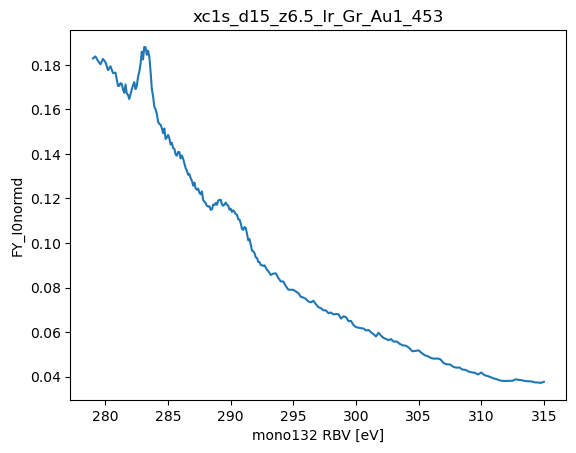

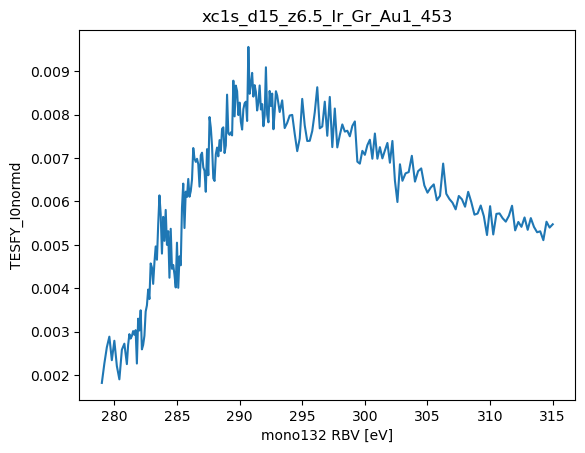

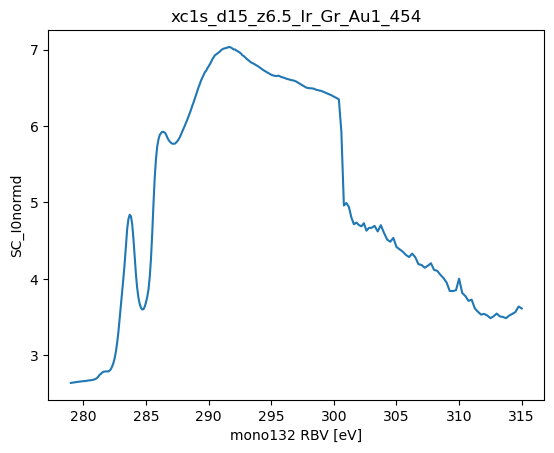

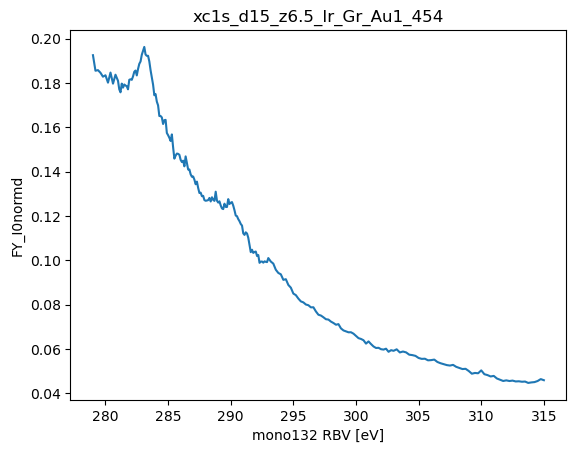

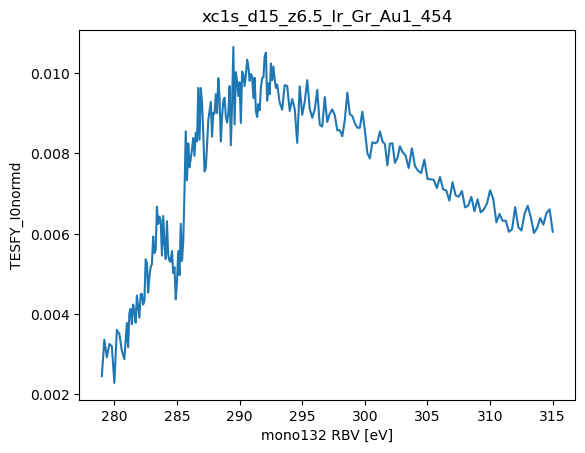

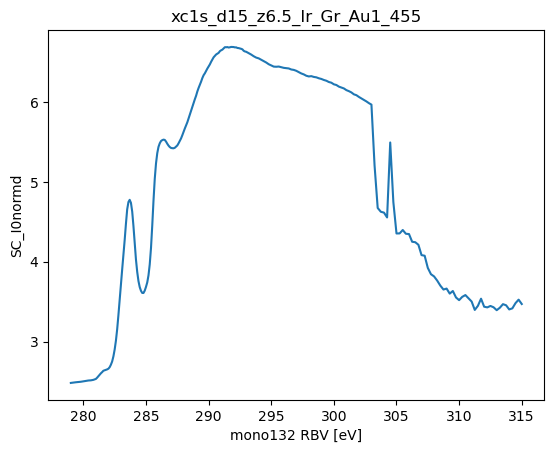

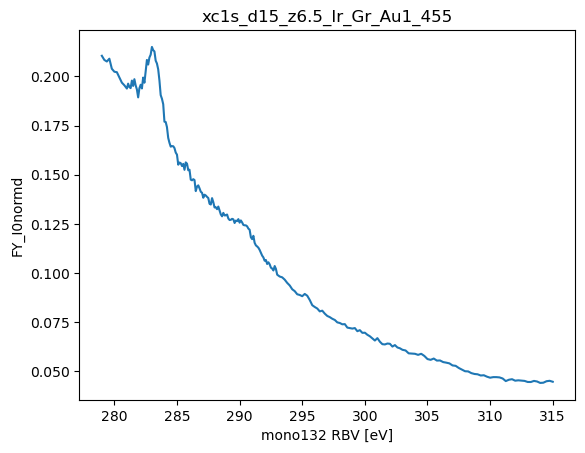

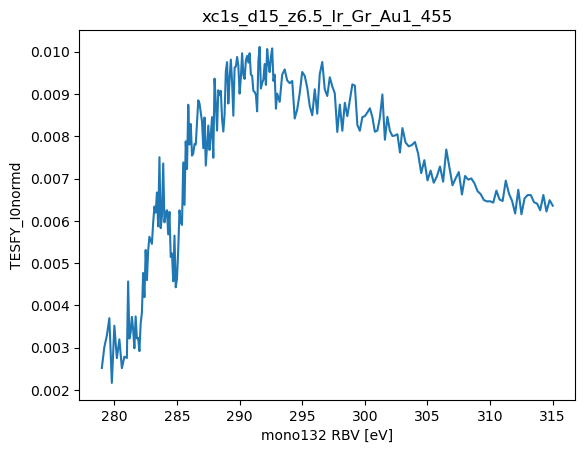

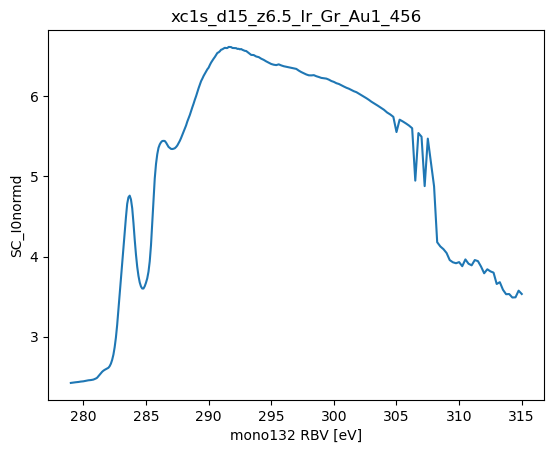

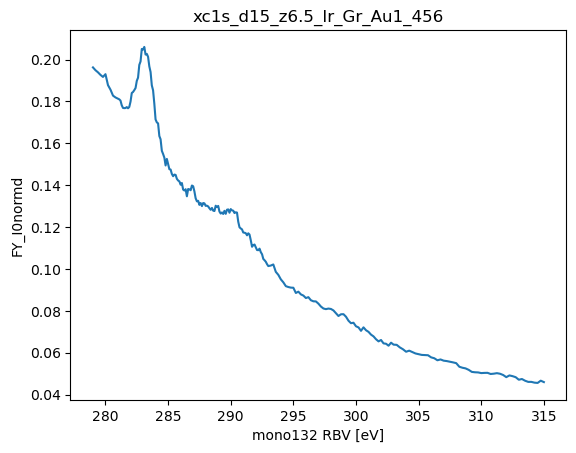

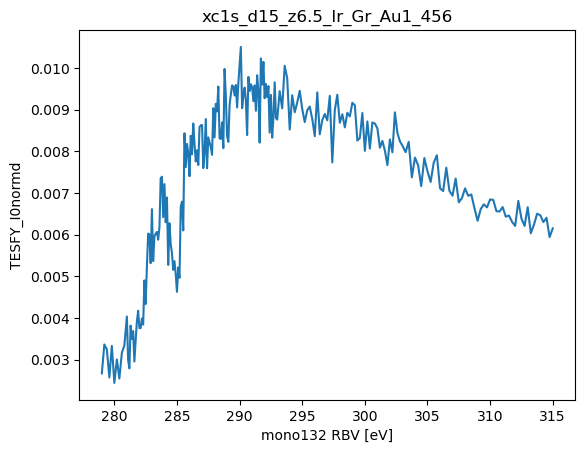

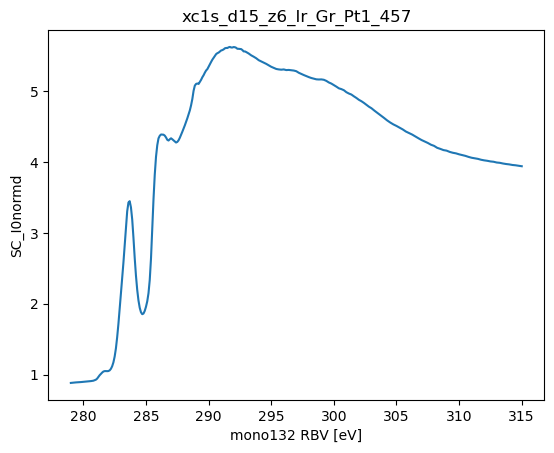

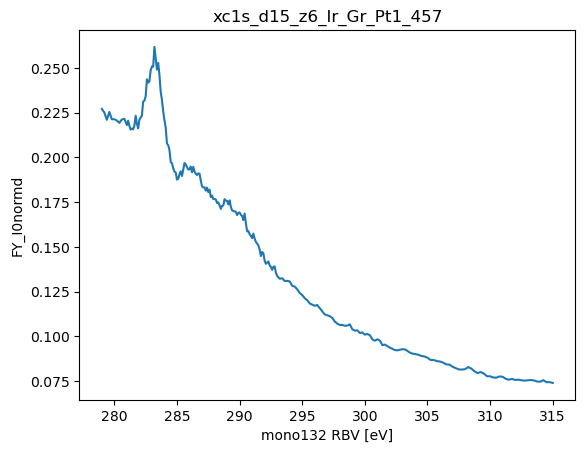

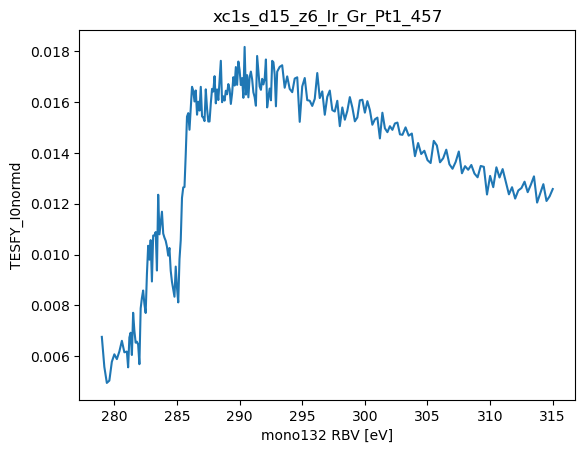

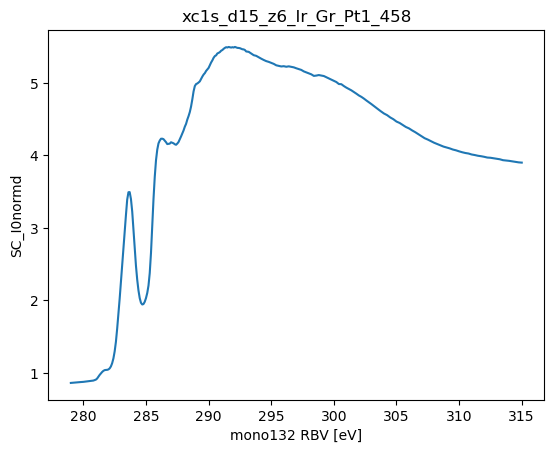

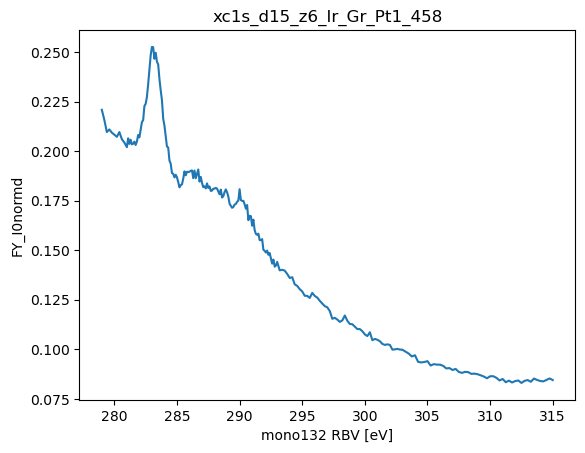

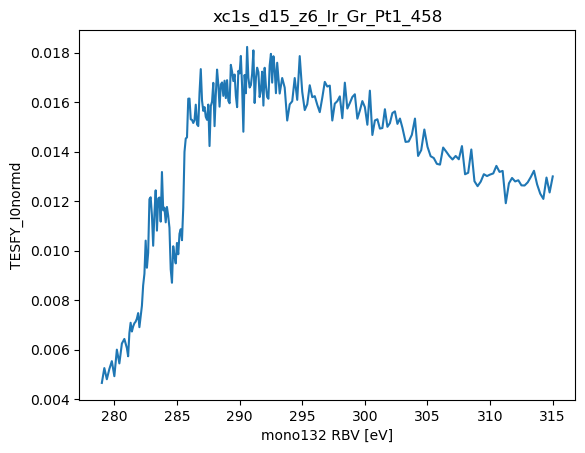

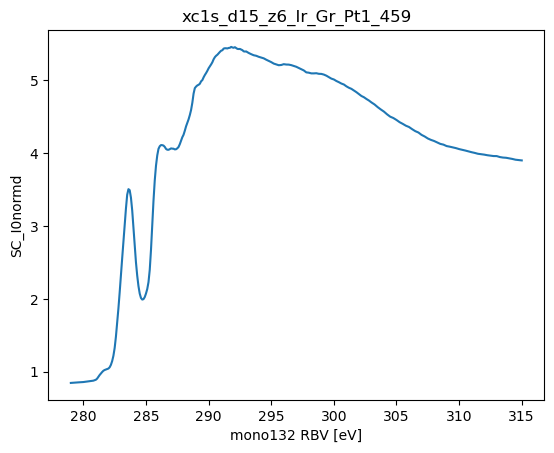

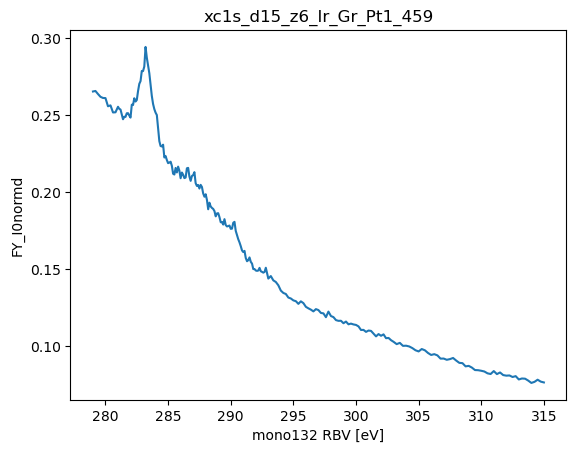

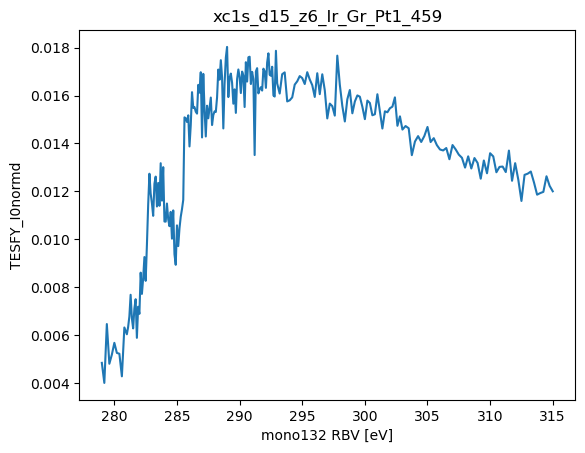

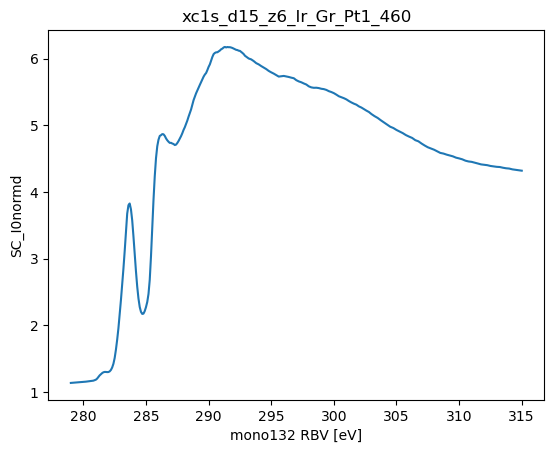

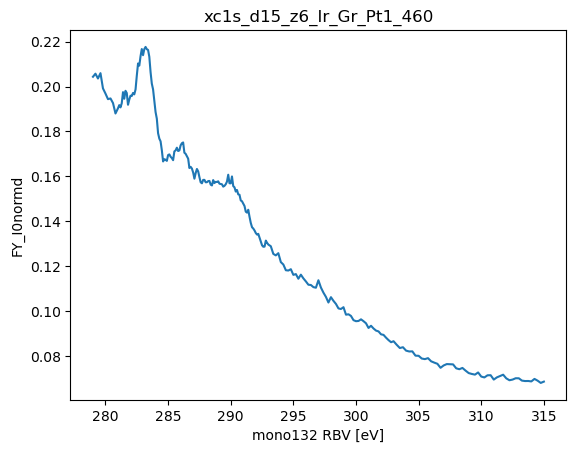

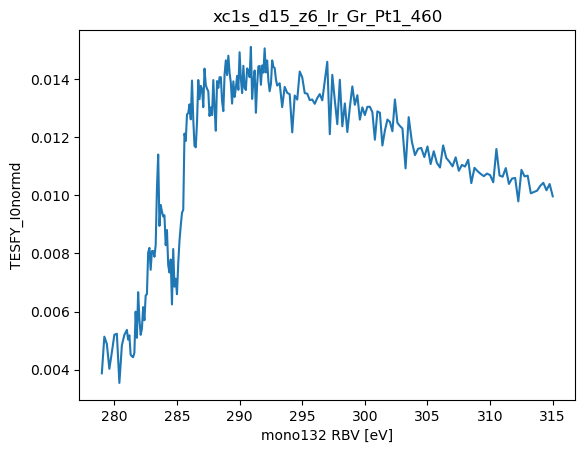

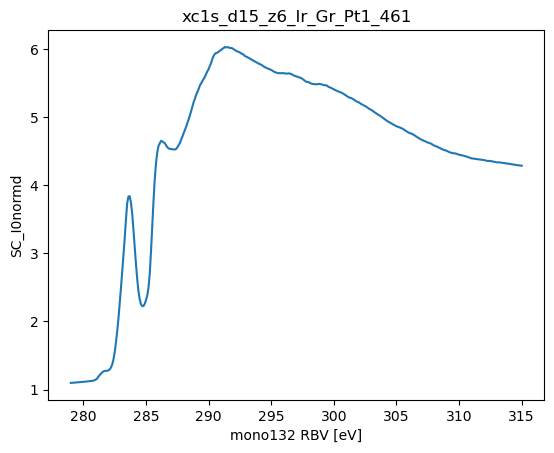

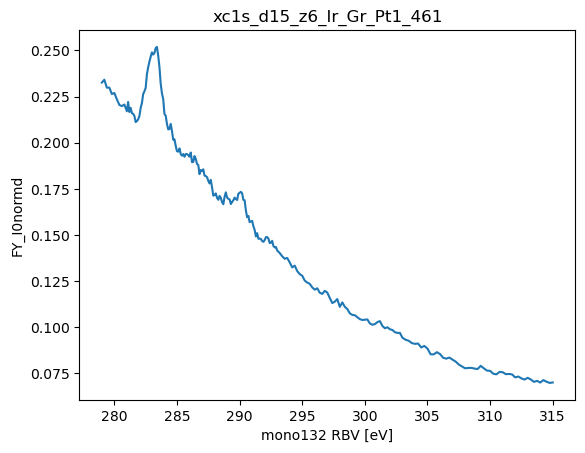

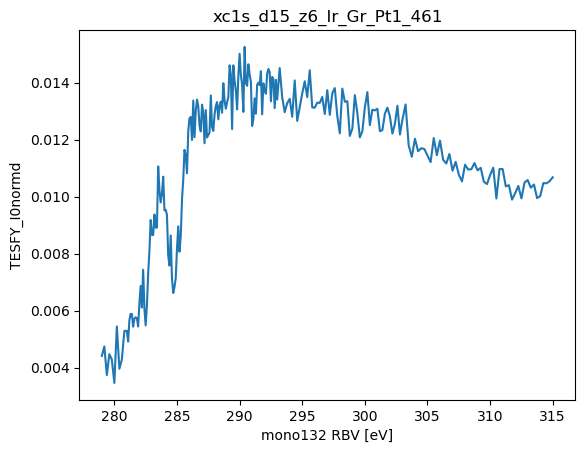

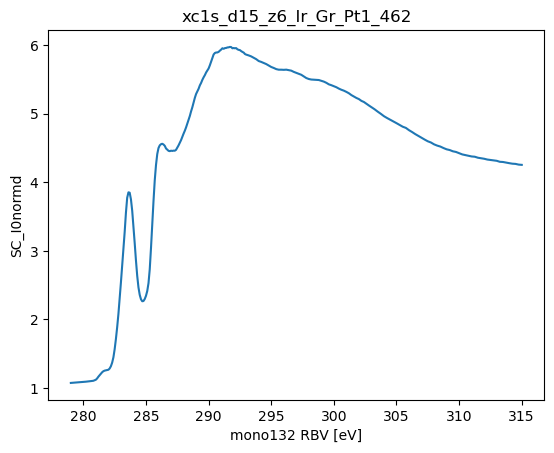

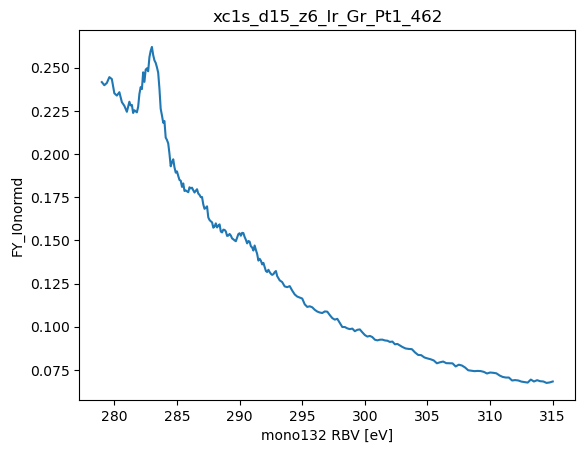

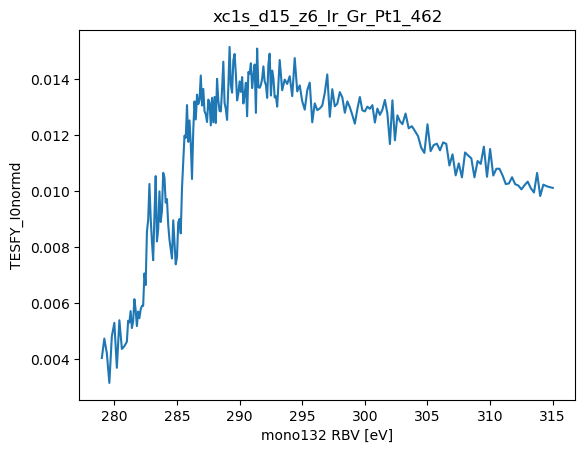

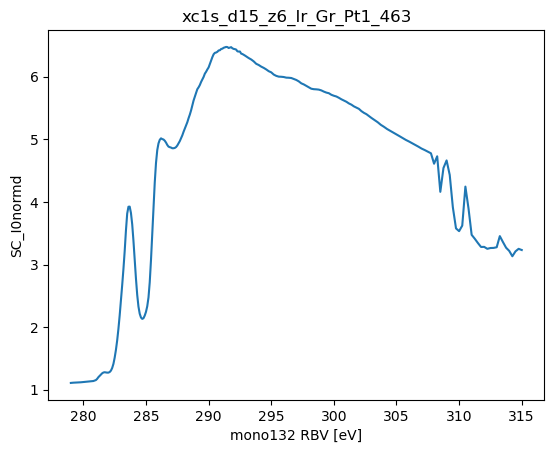

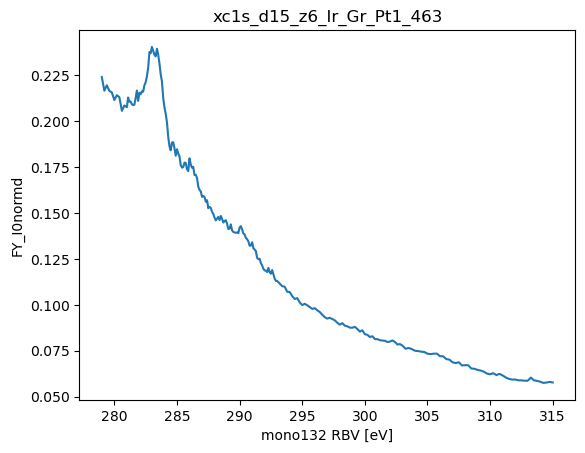

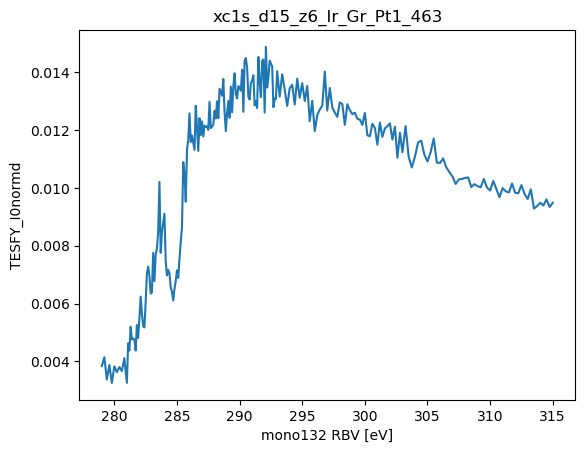

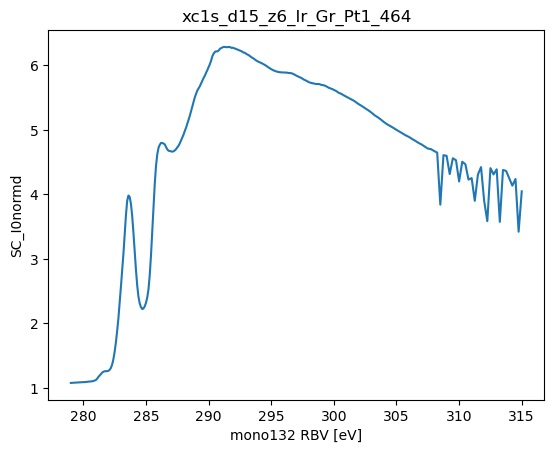

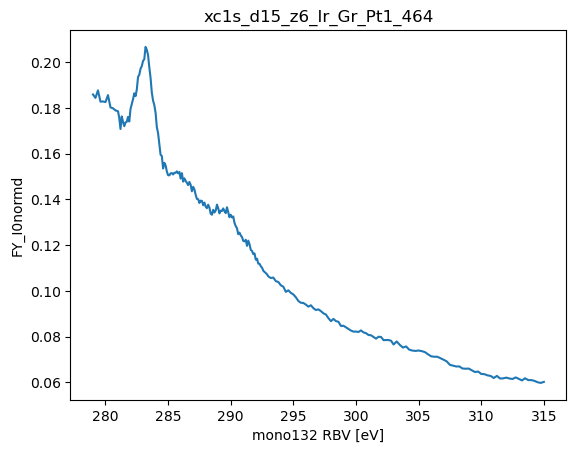

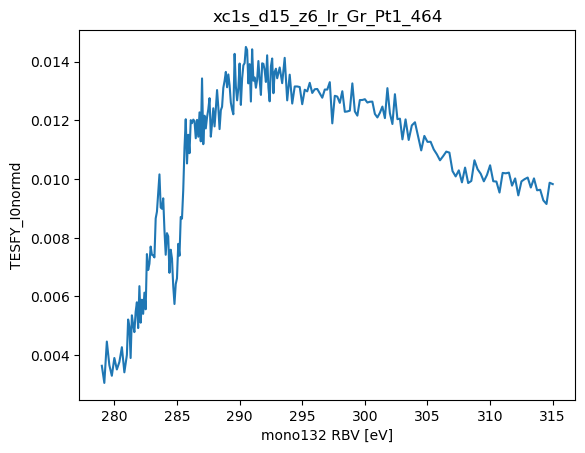

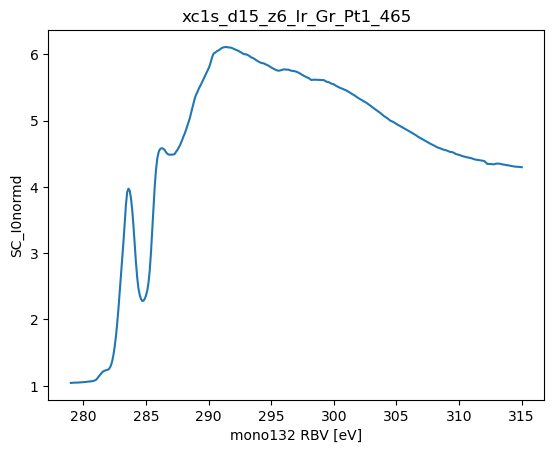

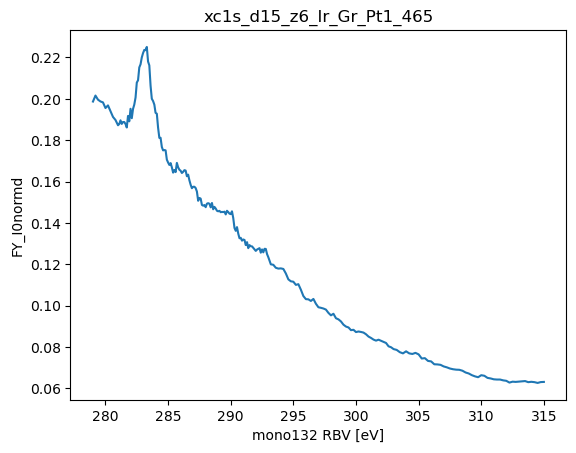

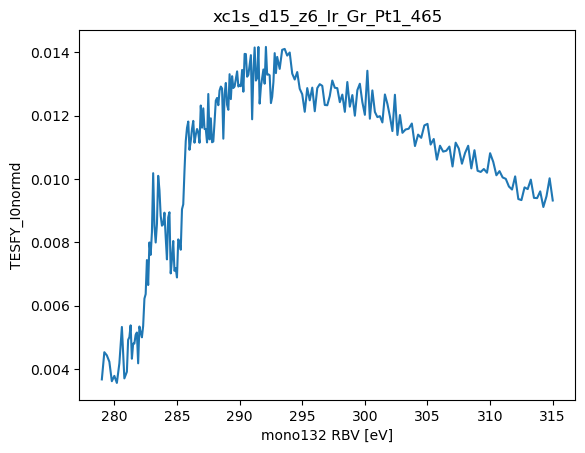

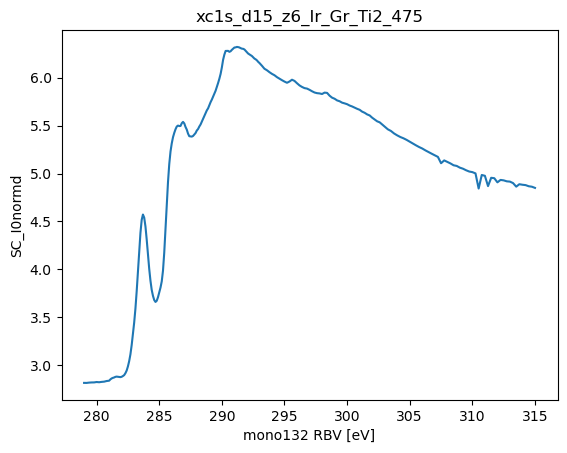

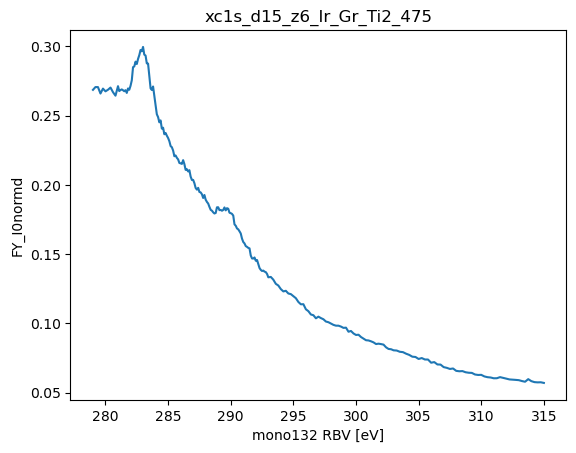

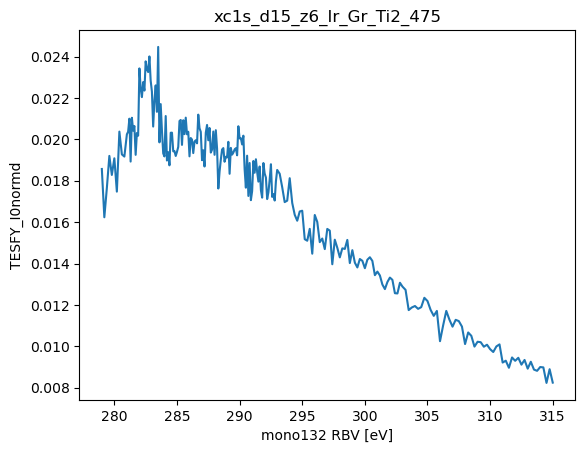

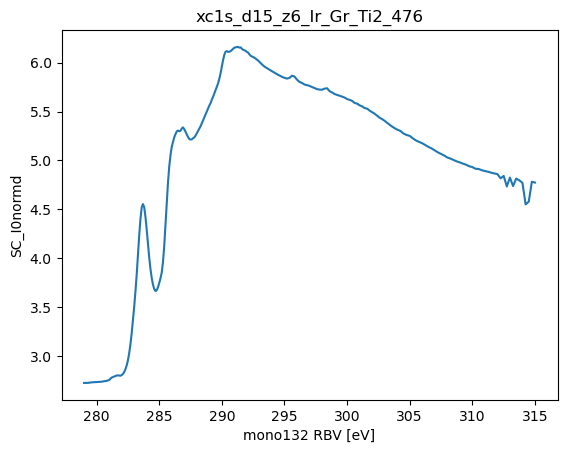

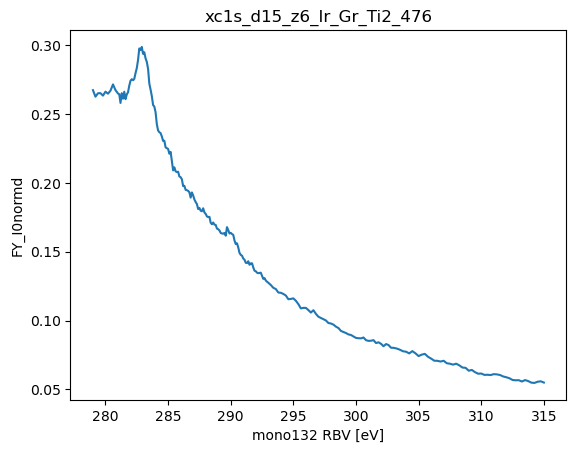

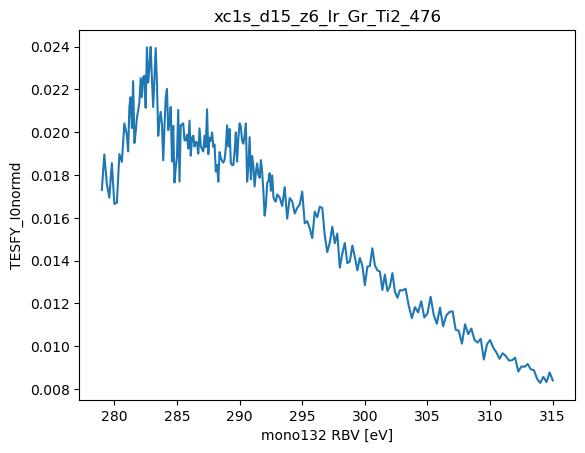

<Figure size 640x480 with 0 Axes>

In [65]:
i=0
for k in load_list:
    #savefilename=home+'plots/'+k+'.pdf'
    SC=df_X[df_X['Sample']==k]['SC']
    FY=df_X[df_X['Sample']==k]['FY']
    TESTFY=df_X[df_X['Sample']==k]['testfy']
    I0=df_X[df_X['Sample']==k]['I0']
    X=df_X[df_X['Sample']==k]['mono132']
    col_label0='SC_I0normd'
    col_label1='FY_I0normd'
    col_label2='TESFY_I0normd'
    #Y0=pd.DataFrame
    Y0=SC/I0
    Y1=FY/I0
    Y2=TESTFY/I0
    df_temp=pd.concat([X,Y0,Y1,Y2],axis=1)
    #col_label0='SC_I0normd'
    #col_label0='SC_I0normd'
    df_temp=df_temp.rename(columns={0: col_label0,1: col_label1,2: col_label2})
    df_temp.to_csv(home+'pandas/'+k+'.csv',index=False)
    if 'xc1s' in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:
       plt.plot(X,Y0)
       plt.title(k)
       plt.ylabel(col_label0)
       plt.xlabel('mono132 RBV [eV]') 
       savefilename=home+'plots/'+k+col_label0+'.pdf'
       plt.savefig(savefilename)
       plt.show
       plt.figure()
        
       plt.plot(X,Y1)
       plt.title(k)
       plt.ylabel(col_label1)
       plt.xlabel('mono132 RBV [eV]') 
       savefilename=home+'plots/'+k+col_label1+'.pdf'
       plt.savefig(savefilename)
       plt.show
       plt.figure() 

       plt.plot(X,Y2)
       plt.title(k)
       plt.ylabel(col_label2)
       plt.xlabel('mono132 RBV [eV]') 
       savefilename=home+'plots/'+k+col_label2+'.pdf'
       plt.savefig(savefilename)
       plt.show
       plt.figure() 

        
       

In [64]:
df_temp

,mono132,SC_I0normd,FY_I0normd,TESFY_I0normd
47072,279.001,2.725028,0.267319,0.017309
47073,279.200,2.725096,0.262574,0.018964
47074,279.400,2.726595,0.265092,0.017576
47075,279.601,2.730894,0.265143,0.016943
47076,279.799,2.732137,0.263361,0.018558
...,...,...,...,...
47296,313.999,4.770720,0.054891,0.008288
47297,314.250,4.550138,0.054691,0.008572
47298,314.501,4.578057,0.055548,0.008328
47299,314.750,4.781751,0.055875,0.008779


In [ ]:
i=0
for k in load_list:
    savefilename=home+'plots/'+k+'.pdf'
    SC=df_X[df_X['Sample']==k]['SC']
    FY=df_X[df_X['Sample']==k]['FY']
    I0=df_X[df_X['Sample']==k]['I0']
    X=df_X[df_X['Sample']==k]['mono132']
    Y=SC/I0

    if 'xc1s' in pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]:
       plt.plot(X,Y)
       plt.title(k)
       plt.ylabel('Drain current/Io mesh current')
       plt.xlabel('mono132 RBV [eV]')
    #plt.show()    
       plt.savefig(savefilename)
       #i=i+1
       plt.show
       if k !=k0:
          plt.figure()
    k0=k
        
       


In [ ]:
 pd.unique(df_X[df_X['Sample']==k]['Sample'])[0]